In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)

df = pd.read_excel(r"C:\AI Search Trend Analysis & Insight Dashboard\EDA\AI_Dataset_Professional.xlsx")
print(df.head())

print("Shape (Rows, Columns):", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

🎉 All required libraries are installed and working perfectly!
Pandas: 3.0.1
NumPy: 2.4.2
Matplotlib: 3.10.8
Seaborn: 0.13.2
     Keyword  Search Interest  Growth %           Category Platform  \
0  ai gemini              100      0.10            Chatbot   Google   
1     gemini               98      0.09            Chatbot   Google   
2  gemini ai               98      0.20            Chatbot   Google   
3  google ai               33     -0.01         General AI   Google   
4  ai summit               32     -0.10  Event / Education    Other   

  Trend Status Popularity Level  
0   Low Growth        Very High  
1   Low Growth        Very High  
2   Low Growth        Very High  
3    Declining              Low  
4    Declining              Low  
Shape (Rows, Columns): (50, 7)

Column Names:
 Index(['Keyword', 'Search Interest', 'Growth %', 'Category', 'Platform',
       'Trend Status', 'Popularity Level'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50 entri

In [3]:
# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Keyword             0
Search Interest     0
Growth %            0
Category            0
Platform            0
Trend Status        0
Popularity Level    0
dtype: int64


In [4]:
# Handle Missing values
df.fillna(0, inplace=True)

,Keyword,Search Interest,Growth %,Category,Platform,Trend Status,Popularity Level
0,ai gemini,100,0.10,Chatbot,Google,Low Growth,Very High
1,gemini,98,0.09,Chatbot,Google,Low Growth,Very High
2,gemini ai,98,0.20,Chatbot,Google,Low Growth,Very High
3,google ai,33,-0.01,General AI,Google,Declining,Low
4,ai summit,32,-0.10,Event / Education,Other,Declining,Low
5,ai video,26,0.07,Video AI,Other,Low Growth,Low
6,ai photo,21,0.06,Image Generation,Other,Low Growth,Low
7,chatgpt ai,20,0.01,Chatbot,OpenAI,Low Growth,Low
8,ai chatgpt,20,-0.02,Chatbot,OpenAI,Declining,Low
9,claude,15,-0.08,Chatbot,Anthropic,Declining,Low


In [5]:
#Basic Data Understanding
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Keyword           50 non-null     str    
 1   Search Interest   50 non-null     int64  
 2   Growth %          50 non-null     float64
 3   Category          50 non-null     str    
 4   Platform          50 non-null     str    
 5   Trend Status      50 non-null     str    
 6   Popularity Level  50 non-null     str    
dtypes: float64(1), int64(1), str(5)
memory usage: 2.9 KB


,Search Interest,Growth %
count,50.000000,50.00000
mean,14.720000,-0.01200
std,22.569656,0.11482
min,3.000000,-0.30000
25%,4.000000,-0.07500
50%,7.500000,0.00500
75%,13.500000,0.08750
max,100.000000,0.20000


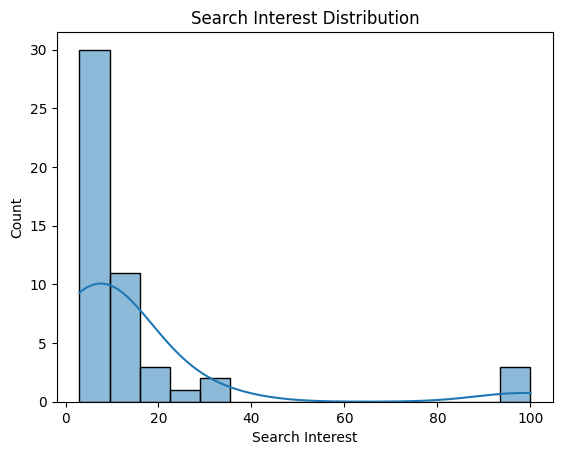

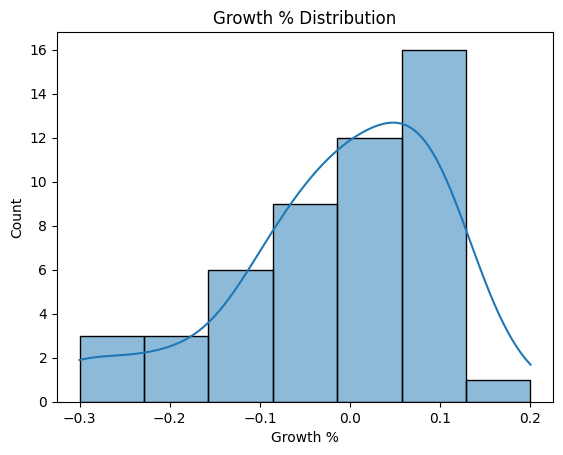

In [6]:
#Univariate Analysis
#Numerical Columns
df['Search Interest'].describe()
df['Growth %'].describe()
sns.histplot(df['Search Interest'], kde=True)
plt.title("Search Interest Distribution")
plt.show()
sns.histplot(df['Growth %'], kde=True)
plt.title("Growth % Distribution")
plt.show()

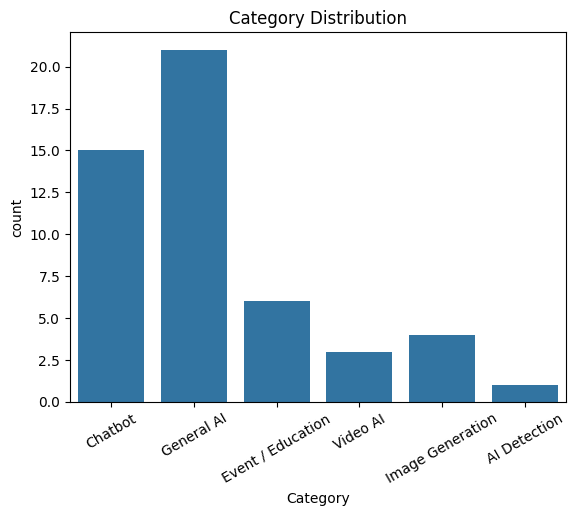

In [7]:
#Categorical Columns
df['Category'].value_counts()
df['Platform'].value_counts()
df['Trend Status'].value_counts()
df['Popularity Level'].value_counts()
sns.countplot(x='Category', data=df)
plt.xticks(rotation=30)
plt.title("Category Distribution")
plt.show()

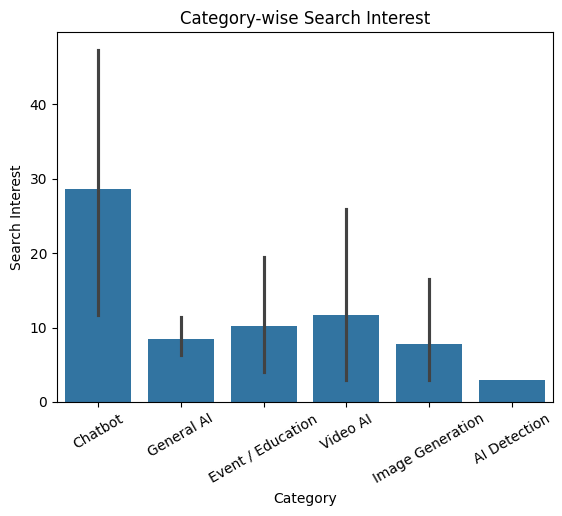

In [8]:
#Bivariate Analysis
#Category vs Search Interest
df.groupby('Category')['Search Interest'].mean().sort_values(ascending=False)
sns.barplot(x='Category', y='Search Interest', data=df)
plt.xticks(rotation=30)
plt.title("Category-wise Search Interest")
plt.show()

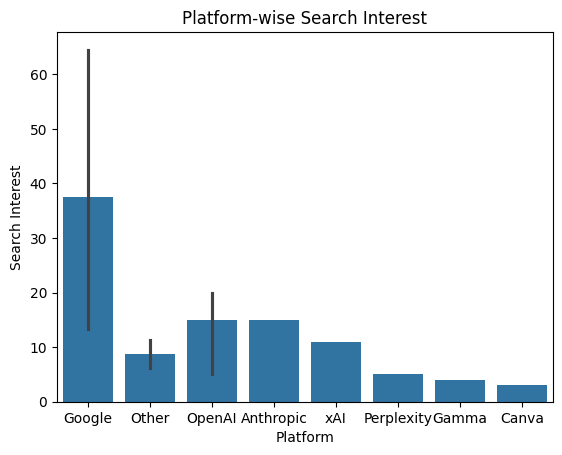

In [9]:
#Platform vs Search Interest
df.groupby('Platform')['Search Interest'].mean().sort_values(ascending=False)
sns.barplot(x='Platform', y='Search Interest', data=df)
plt.title("Platform-wise Search Interest")
plt.show()

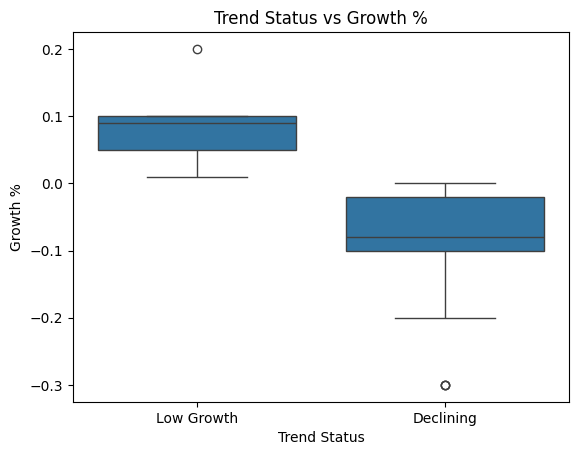

In [10]:
#Trend Status vs Growth %
df.groupby('Trend Status')['Growth %'].mean()
sns.boxplot(x='Trend Status', y='Growth %', data=df)
plt.title("Trend Status vs Growth %")
plt.show()

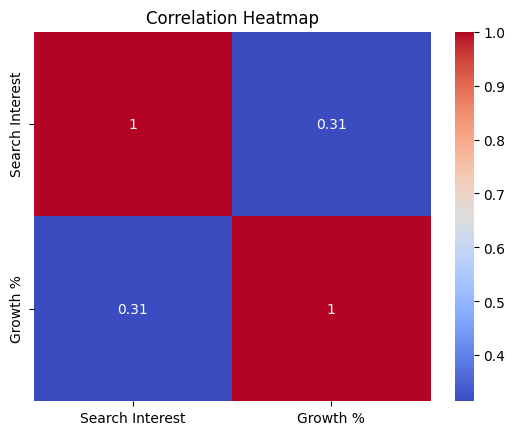

In [11]:
#Multivariate Analysis
#Correlation Heatmap
sns.heatmap(df[['Search Interest','Growth %']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
#Key Insights in this Dataset
#Most Popular AI Keywords
df.sort_values(by='Search Interest', ascending=False).head(10)

,Keyword,Search Interest,Growth %,Category,Platform,Trend Status,Popularity Level
0,ai gemini,100,0.10,Chatbot,Google,Low Growth,Very High
1,gemini,98,0.09,Chatbot,Google,Low Growth,Very High
2,gemini ai,98,0.20,Chatbot,Google,Low Growth,Very High
3,google ai,33,-0.01,General AI,Google,Declining,Low
4,ai summit,32,-0.10,Event / Education,Other,Declining,Low
5,ai video,26,0.07,Video AI,Other,Low Growth,Low
6,ai photo,21,0.06,Image Generation,Other,Low Growth,Low
7,chatgpt ai,20,0.01,Chatbot,OpenAI,Low Growth,Low
8,ai chatgpt,20,-0.02,Chatbot,OpenAI,Declining,Low
9,claude,15,-0.08,Chatbot,Anthropic,Declining,Low


In [13]:
#Most Trending AI Category
df.groupby('Category')['Search Interest'].mean().sort_values(ascending=False)

Category
Chatbot              28.600000
Video AI             11.666667
Event / Education    10.166667
General AI            8.428571
Image Generation      7.750000
AI Detection          3.000000
Name: Search Interest, dtype: float64

In [14]:
#Platform Dominance
df.groupby('Platform')['Search Interest'].mean().sort_values(ascending=False)

Platform
Google        37.500000
Anthropic     15.000000
OpenAI        15.000000
xAI           11.000000
Other          8.678571
Perplexity     5.000000
Gamma          4.000000
Canva          3.000000
Name: Search Interest, dtype: float64

In [15]:
#Growth Trend Patterns
df['Trend Status'].value_counts()

Trend Status
Low Growth    25
Declining     25
Name: count, dtype: int64

In [16]:
#High Growth Opportunities
df.sort_values(by='Growth %', ascending=False).head(5)

,Keyword,Search Interest,Growth %,Category,Platform,Trend Status,Popularity Level
2,gemini ai,98,0.2,Chatbot,Google,Low Growth,Very High
0,ai gemini,100,0.1,Chatbot,Google,Low Growth,Very High
14,grok,11,0.1,Chatbot,xAI,Low Growth,Low
48,free ai video generator,3,0.1,Video AI,Other,Low Growth,Low
43,gemini ai prompt,3,0.1,Chatbot,Google,Low Growth,Low
